## Diseño del esquema de datos

El dataset **Teen Mental Health** contiene información sobre hábitos de uso de redes sociales, sueño, actividad física, rendimiento académico y variables relacionadas con la salud mental en adolescentes.

Cada fila representa un adolescente encuestado y reúne información comportamental y emocional que permitirá realizar análisis exploratorios y modelado de datos en Apache Spark.

Se define una única entidad denominada **Teen_Mental_Health**, ya que cada registro contiene toda la información asociada a un participante.

Debido a que el conjunto de datos no incluye una llave primaria natural, se generará un identificador único denominado **id** durante el procesamiento de los datos.

### 📚Diccionario de datos

| Campo | Tipo Spark | Llave | Nulable | Descripción |
|---------|---------|---------|---------|---------|
| id | LongType | PK | No | Identificador único generado |
| age | IntegerType | No | Sí | Edad del adolescente |
| gender | StringType | No | Sí | Género del participante |
| daily_social_media_hours | DoubleType | No | Sí | Horas promedio diarias de uso de redes sociales |
| platform_usage | StringType | No | Sí | Plataforma más utilizada |
| sleep_hours | DoubleType | No | Sí | Horas promedio de sueño |
| screen_time_before_sleep | DoubleType | No | Sí | Tiempo frente a pantallas antes de dormir |
| academic_performance | DoubleType | No | Sí | Indicador de desempeño académico |
| physical_activity | DoubleType | No | Sí | Horas promedio de actividad física |
| social_interaction_level | StringType | No | Sí | Nivel de interacción social (Low, Medium, High) |
| stress_level | IntegerType | No | Sí | Nivel de estrés en escala de 1 a 10 |
| anxiety_level | IntegerType | No | Sí | Nivel de ansiedad en escala de 1 a 10 |
| depression_risk | StringType | No | Sí | Riesgo de depresión (Low, Medium, High) |

### Modelo lógico

TEEN_MENTAL_HEALTH

├── id (PK)
├── age
├── gender
├── daily_social_media_hours
├── platform_usage
├── sleep_hours
├── screen_time_before_sleep
├── academic_performance
├── physical_activity
├── social_interaction_level
├── stress_level
├── anxiety_level
└── depression_risk

### Justificación del diseño

Se utiliza una estructura de una sola entidad debido a que el dataset ya contiene toda la información de cada participante en un único registro. No fue necesario separar la información en múltiples tablas, ya que cada fila incluye variables demográficas, académicas, de comportamiento digital y de salud mental asociadas a un mismo adolescente.

Los atributos fueron clasificados según su naturaleza:

- Variables numéricas continuas: horas de uso, sueño, actividad física y rendimiento académico.
- Variables categóricas: género, plataforma utilizada, nivel de interacción social y riesgo de depresión.
- Variables numéricas discretas: niveles de estrés y ansiedad.

### Definición del esquema de datos mediante StructType

In [0]:
from pyspark.sql.types import *

schema = StructType([
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("daily_social_media_hours", DoubleType(), True),
    StructField("platform_usage", StringType(), True),
    StructField("sleep_hours", DoubleType(), True),
    StructField("screen_time_before_sleep", DoubleType(), True),
    StructField("academic_performance", DoubleType(), True),
    StructField("physical_activity", DoubleType(), True),
    StructField("social_interaction_level", StringType(), True),
    StructField("stress_level", IntegerType(), True),
    StructField("anxiety_level", IntegerType(), True),
    StructField("depression_risk", StringType(), True)
])


El esquema definido mediante StructType será utilizado durante la lectura del archivo CSV para garantizar que cada atributo sea interpretado con el tipo de dato correspondiente.

La definición explícita del esquema evita errores asociados a la inferencia automática de tipos y garantiza consistencia durante el procesamiento y posterior almacenamiento de la información en formato Delta.

### Lectura de dataset

In [0]:
df = spark.read.csv(
    "/Volumes/workspace/default/mental_health_vol/Teen_Mental_Health_Dataset.csv",
    header=True,
    schema=schema
)

display(df)

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk
19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium
16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high
17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low
19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium
15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low
17,female,5.2,Instagram,6.0,2.9,2.87,1.3,low,7,7,medium
17,male,5.6,Other,5.3,2.4,2.04,0.4,medium,10,10,high
19,female,5.8,Instagram,6.1,1.2,2.62,0.9,high,8,7,high
14,female,1.8,Other,6.8,2.0,3.49,1.3,low,2,2,low
15,male,7.6,Both,4.3,2.3,2.0,0.1,medium,10,8,high


### Generación de identificador único
El conjunto de datos original no contiene una llave primaria que permita identificar de manera única cada registro. Por esta razón, se agregó una columna denominada id utilizando la función monotonically_increasing_id() de PySpark.

In [0]:
from pyspark.sql.functions import monotonically_increasing_id

df = df.withColumn(
    "id",
    monotonically_increasing_id()
)

display(df.limit(10))

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id
19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium,0
16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high,1
17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low,2
19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium,3
15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low,4
17,female,5.2,Instagram,6.0,2.9,2.87,1.3,low,7,7,medium,5
17,male,5.6,Other,5.3,2.4,2.04,0.4,medium,10,10,high,6
19,female,5.8,Instagram,6.1,1.2,2.62,0.9,high,8,7,high,7
14,female,1.8,Other,6.8,2.0,3.49,1.3,low,2,2,low,8
15,male,7.6,Both,4.3,2.3,2.0,0.1,medium,10,8,high,9


### Calidad y limpieza de datos

In [0]:
from pyspark.sql.functions import col, count, when

nulos = df.select([
    count(
        when(col(c).isNull(), c)
    ).alias(c)
    for c in df.columns
])

display(nulos)

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id
0,0,0,0,0,0,0,0,0,0,0,0,0


**Validar registros duplicados**

In [0]:
print("Total registros:", df.count())
print("Registros únicos:", df.dropDuplicates().count())

Total registros: 2500
Registros únicos: 2500


In [0]:
duplicados = df.groupBy(df.columns).count().filter("count > 1")
display(duplicados)

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id,count


In [0]:
from pyspark.sql.functions import length, trim, col

df.filter(
    length(col("gender")) != length(trim(col("gender")))
).show()

+---+------+------------------------+--------------+-----------+------------------------+--------------------+-----------------+------------------------+------------+-------------+---------------+---+
|age|gender|daily_social_media_hours|platform_usage|sleep_hours|screen_time_before_sleep|academic_performance|physical_activity|social_interaction_level|stress_level|anxiety_level|depression_risk| id|
+---+------+------------------------+--------------+-----------+------------------------+--------------------+-----------------+------------------------+------------+-------------+---------------+---+
+---+------+------------------------+--------------+-----------+------------------------+--------------------+-----------------+------------------------+------------+-------------+---------------+---+




#### Conclusión
La validación de nulabilidad realizada sobre todas las columnas del dataset confirmó la ausencia de valores nulos. Esto indica que la información se encuentra completa y no requiere procesos adicionales de imputación o eliminación de registros antes de su análisis y almacenamiento.

### Configuración del entorno de ejecución

Para el desarrollo de la actividad se utilizó Databricks Community Edition como plataforma de procesamiento distribuido basada en Apache Spark.

A continuación se presenta la configuración del clúster utilizado para la ejecución de los notebooks.

In [0]:
%python
import sys

print("  Spark version:   " + spark.version)
print("  Python version:  " + sys.version.split()[0])
print("  Modo de computo: Serverless (Unity Catalog)")
print("  Runtime:         Databricks Serverless")
print("\nEstructura de almacenamiento:")
print("  Tipo:    Unity Catalog - Volumes")
print("  Catalog: workspace")
print("  Schema:  default")
print("  Volume:  mental_health_vol")
print("  Ruta:    /Volumes/workspace/default/mental_health_vol/")



  Spark version:   4.1.0
  Python version:  3.12.3
  Modo de computo: Serverless (Unity Catalog)
  Runtime:         Databricks Serverless

Estructura de almacenamiento:
  Tipo:    Unity Catalog - Volumes
  Catalog: workspace
  Schema:  default
  Volume:  mental_health_vol
  Ruta:    /Volumes/workspace/default/mental_health_vol/


La práctica fue desarrollada en la plataforma Databricks utilizando un entorno de cómputo Serverless con soporte para Unity Catalog.

La configuración del entorno fue validada mediante la ejecución de comandos dentro del Notebook, permitiendo identificar las versiones de Apache Spark y Python utilizadas durante el procesamiento de los datos.

## Características del entorno

- Modo de cómputo: Serverless.
- Runtime: Databricks Serverless.
- Gestión de almacenamiento: Unity Catalog Volumes.
- Catálogo utilizado: workspace.
- Esquema utilizado: default.
- Volumen utilizado: mental_health_vol.
- Ruta de almacenamiento: `/Volumes/workspace/default/mental_health_vol/`.

## Verificación de versiones

Para identificar la configuración del entorno se utilizaron las siguientes instrucciones:

- `spark.version`
- `spark.sparkContext.getConf().getAll()`

Estas funciones permiten consultar la versión del motor Apache Spark y los parámetros de configuración activos durante la ejecución del Notebook.

## Consideraciones sobre la infraestructura

Debido a que el entorno utilizado corresponde a una infraestructura Serverless administrada por Databricks, los recursos físicos de cómputo (núcleos, memoria RAM y configuración detallada de autoscaling) no son expuestos directamente al usuario. La asignación de recursos es gestionada automáticamente por la plataforma según la carga de trabajo y las necesidades de ejecución.

La Figura 1 presenta la configuración general del entorno Serverless utilizado para el desarrollo de la práctica.


**Figura 1. Configuración del entorno Serverless en Databricks.**

![image_1780709836664.png](./image_1780709836664.png "image_1780709836664.png")

![image_1780718189543.png](./image_1780718189543.png "image_1780718189543.png")


### Creacion de la tabla

**Carga del dataset en Apache Spark**

Una vez disponible el archivo dentro del volumen de Unity Catalog, se procedió a su lectura mediante Apache Spark utilizando la función `spark.read.csv()`.

Durante la carga se habilitó la lectura de encabezados y la inferencia automática de tipos de datos para construir el DataFrame que será utilizado en las etapas de análisis y persistencia.


In [0]:
%python
from pyspark.sql.functions import monotonically_increasing_id

df = spark.read.csv(
    "/Volumes/workspace/default/mental_health_vol/Teen_Mental_Health_Dataset.csv",
    header=True,
    inferSchema=True
)

df = df.withColumn("id", monotonically_increasing_id())

df.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("mental_health_db.teen_mental_health")

print(f"✅ Tabla creada con {df.count()} filas y {len(df.columns)} columnas")

✅ Tabla creada con 2500 filas y 13 columnas


In [0]:
print(
    "Tabla creada:",
    spark.catalog.tableExists("mental_health_db.teen_mental_health")
)

Tabla creada: True


La carga del archivo fue realizada exitosamente. Se verificó la correcta lectura de los registros y se añadió una columna identificadora para facilitar la trazabilidad de la información dentro del entorno Spark.



### Persistencia de datos

Una vez cargado el dataset en Apache Spark, los datos fueron almacenados en formato Delta Lake mediante la creación de una tabla persistente.

La persistencia de los datos permite mantener la información disponible para futuras consultas y análisis, aprovechando las capacidades de almacenamiento optimizado de Delta Lake dentro de Databricks.

### Lectura y Recuentos

In [0]:
display(df.limit(10))

print("Cantidad de registros:", df.count())
print("Cantidad de columnas:", len(df.columns))

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id
19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium,0
16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high,1
17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low,2
19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium,3
15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low,4
17,female,5.2,Instagram,6.0,2.9,2.87,1.3,low,7,7,medium,5
17,male,5.6,Other,5.3,2.4,2.04,0.4,medium,10,10,high,6
19,female,5.8,Instagram,6.1,1.2,2.62,0.9,high,8,7,high,7
14,female,1.8,Other,6.8,2.0,3.49,1.3,low,2,2,low,8
15,male,7.6,Both,4.3,2.3,2.0,0.1,medium,10,8,high,9


Cantidad de registros: 2500
Cantidad de columnas: 13


### Confirmacion de creacion tabla

La validación mediante consultas SQL permitió confirmar la existencia de la tabla y la correcta definición de su estructura.

In [0]:
%sql
SHOW TABLES IN mental_health_db;

database,tableName,isTemporary
mental_health_db,teen_mental_health,false
mental_health_db,teen_mental_health_ddl,false
mental_health_db,teen_social_media,false


### Consultar la tabla creada

In [0]:
%sql
SELECT * FROM mental_health_db.teen_mental_health LIMIT 10;

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id
19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium,0
16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high,1
17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low,2
19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium,3
15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low,4
17,female,5.2,Instagram,6.0,2.9,2.87,1.3,low,7,7,medium,5
17,male,5.6,Other,5.3,2.4,2.04,0.4,medium,10,10,high,6
19,female,5.8,Instagram,6.1,1.2,2.62,0.9,high,8,7,high,7
14,female,1.8,Other,6.8,2.0,3.49,1.3,low,2,2,low,8
15,male,7.6,Both,4.3,2.3,2.0,0.1,medium,10,8,high,9


### Confirmar la ubicación

In [0]:
%sql
DESCRIBE DETAIL mental_health_db.teen_mental_health;

format,id,name,description,location,createdAt,lastModified,partitionColumns,clusteringColumns,numFiles,sizeInBytes,properties,minReaderVersion,minWriterVersion,tableFeatures,statistics,clusterByAuto
delta,ce1b068a-32a1-4548-968c-ce6cd9df5ebd,workspace.mental_health_db.teen_mental_health,null,,2026-06-05T04:56:37.580Z,2026-06-07T21:15:43.000Z,List(),List(),1,24212,"Map(delta.parquet.compression.codec -> zstd, delta.enableDeletionVectors -> true)",3,7,"List(appendOnly, deletionVectors, invariants)","Map(numRowsDeletedByDeletionVectors -> 0, numDeletionVectors -> 0)",false


Los datos fueron almacenados exitosamente en una tabla Delta denominada `mental_health_db.teen_mental_health`. La validación mediante consultas SQL permitió confirmar la existencia de la tabla y la correcta definición de su estructura.


### Validación de metadatos

Una vez creada la tabla Delta, se realizaron validaciones sobre los metadatos con el fin de verificar la estructura de los datos almacenados, los tipos de datos de cada columna y la definición de la tabla dentro del catálogo.

Las validaciones se realizaron utilizando herramientas de Apache Spark y consultas SQL, permitiendo confirmar la consistencia entre el DataFrame original y la tabla persistida.


### Validacion esquema en Spark

In [0]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- daily_social_media_hours: double (nullable = true)
 |-- platform_usage: string (nullable = true)
 |-- sleep_hours: double (nullable = true)
 |-- screen_time_before_sleep: double (nullable = true)
 |-- academic_performance: double (nullable = true)
 |-- physical_activity: double (nullable = true)
 |-- social_interaction_level: string (nullable = true)
 |-- stress_level: integer (nullable = true)
 |-- anxiety_level: integer (nullable = true)
 |-- depression_risk: string (nullable = true)
 |-- id: long (nullable = false)



La función `printSchema()` permite visualizar la estructura del DataFrame cargado en Spark, mostrando el nombre de las columnas, su tipo de dato y la nulabilidad de cada atributo.

### Descripcion de la tabla 

In [0]:
%sql
DESCRIBE TABLE mental_health_db.teen_mental_health;

col_name,data_type,comment
age,int,null
gender,string,null
daily_social_media_hours,double,null
platform_usage,string,null
sleep_hours,double,null
screen_time_before_sleep,double,null
academic_performance,double,null
physical_activity,double,null
social_interaction_level,string,null
stress_level,int,null


La instrucción `DESCRIBE TABLE` permite consultar los metadatos almacenados en la tabla Delta, verificando que las columnas y los tipos de datos coincidan con la estructura esperada.


### Definición de la tabla

In [0]:
%sql
SHOW CREATE TABLE mental_health_db.teen_mental_health;

createtab_stmt
"CREATE TABLE workspace.mental_health_db.teen_mental_health ( age INT, gender STRING COLLATE UTF8_BINARY, daily_social_media_hours DOUBLE, platform_usage STRING COLLATE UTF8_BINARY, sleep_hours DOUBLE, screen_time_before_sleep DOUBLE, academic_performance DOUBLE, physical_activity DOUBLE, social_interaction_level STRING COLLATE UTF8_BINARY, stress_level INT, anxiety_level INT, depression_risk STRING COLLATE UTF8_BINARY, id BIGINT) USING delta TBLPROPERTIES ( 'delta.enableDeletionVectors' = 'true', 'delta.feature.appendOnly' = 'supported', 'delta.feature.deletionVectors' = 'supported', 'delta.feature.invariants' = 'supported', 'delta.minReaderVersion' = '3', 'delta.minWriterVersion' = '7', 'delta.parquet.compression.codec' = 'zstd')"


La instrucción `SHOW CREATE TABLE` muestra la sentencia SQL utilizada para crear la tabla. Esta validación permite confirmar el formato de almacenamiento, el nombre de la tabla y las propiedades asociadas al objeto persistido.


### Descripcion de datos

Con el fin de obtener una visión general del conjunto de datos, se realizaron estadísticas descriptivas sobre las variables numéricas utilizando funcionalidades de Apache Spark y consultas SQL.

Estas métricas permiten conocer la cantidad de registros, valores promedio, desviación estándar, mínimos y máximos presentes en el dataset.


### Descripción en PySpark


In [0]:
df.describe().show()

+-------+------------------+------+------------------------+--------------+------------------+------------------------+--------------------+------------------+------------------------+------------------+------------------+---------------+-----------------+
|summary|               age|gender|daily_social_media_hours|platform_usage|       sleep_hours|screen_time_before_sleep|academic_performance| physical_activity|social_interaction_level|      stress_level|     anxiety_level|depression_risk|               id|
+-------+------------------+------+------------------------+--------------+------------------+------------------------+--------------------+------------------+------------------------+------------------+------------------+---------------+-----------------+
|  count|              2500|  2500|                    2500|          2500|              2500|                    2500|                2500|              2500|                    2500|              2500|              2500|       

La función `describe()` genera estadísticas descriptivas básicas para las columnas numéricas y categóricas del DataFrame. Entre las métricas calculadas se encuentran el número de registros, promedio, desviación estándar, valor mínimo y valor máximo.


### Estadísticas agregadas en SQL

In [0]:
%sql
SELECT
    COUNT(*) AS total_registros,
    ROUND(AVG(age),2) AS edad_promedio,
    ROUND(AVG(daily_social_media_hours),2) AS promedio_horas_redes,
    ROUND(AVG(sleep_hours),2) AS promedio_horas_sueno,
    ROUND(AVG(stress_level),2) AS promedio_estres,
    ROUND(AVG(anxiety_level),2) AS promedio_ansiedad
FROM mental_health_db.teen_mental_health;

total_registros,edad_promedio,promedio_horas_redes,promedio_horas_sueno,promedio_estres,promedio_ansiedad
2500,15.98,4.46,6.19,5.6,5.16


La consulta SQL calcula indicadores agregados relevantes del conjunto de datos, permitiendo identificar tendencias generales relacionadas con la edad, el uso de redes sociales, las horas de sueño y los niveles promedio de estrés y ansiedad de los participantes.


### Distribución del riesgo de depresión

In [0]:
%sql
SELECT 
    depression_risk,
    COUNT(*)        AS total,
    ROUND(AVG(stress_level), 2)   AS avg_stress,
    ROUND(AVG(anxiety_level), 2)  AS avg_anxiety,
    ROUND(AVG(daily_social_media_hours), 2) AS avg_social_media_hrs
FROM mental_health_db.teen_mental_health
GROUP BY depression_risk
ORDER BY total DESC;

depression_risk,total,avg_stress,avg_anxiety,avg_social_media_hrs
low,1266,3.17,2.87,2.97
medium,650,7.16,6.65,5.42
high,584,9.11,8.49,6.6


### Análisis descriptivo 

Con el fin de obtener una visión general de las características de los participantes según su nivel de riesgo de depresión, se calcularon métricas agregadas utilizando SQL.

La consulta agrupa los registros por la variable `depression_risk` y calcula:

* Cantidad de registros por categoría.
* Nivel promedio de estrés.
* Nivel promedio de ansiedad.
* Promedio de horas diarias de uso de redes sociales.

Estos indicadores permiten identificar posibles diferencias entre los grupos de riesgo y explorar relaciones entre el uso de redes sociales y variables asociadas a la salud mental.



**Hallazgo: mayor riesgo de depresión, más horas en redes sociales y mayores niveles de estrés y ansiedad.**

### Comparación de consultas SELECT y GROUP BY en Spark y SQL

Con el fin de validar la consistencia de los resultados obtenidos mediante diferentes interfaces de consulta, se realizó una operación de agregación utilizando tanto PySpark como SQL.

La consulta agrupa los registros según el nivel de riesgo de depresión (`depression_risk`) y contabiliza la cantidad de registros pertenecientes a cada categoría.

Los resultados obtenidos deben ser equivalentes independientemente del lenguaje utilizado para realizar la consulta.


In [0]:
from pyspark.sql.functions import avg, round, count

df.groupBy("depression_risk") \
  .agg(
      count("*").alias("total"),
      round(avg("stress_level"), 2).alias("avg_stress"),
      round(avg("anxiety_level"), 2).alias("avg_anxiety"),
      round(avg("daily_social_media_hours"), 2).alias("avg_social_media_hrs")
  ) \
  .orderBy("total", ascending=False) \
  .show()

La función `groupBy()` permite agrupar los registros por categoría de riesgo de depresión, mientras que `count()` contabiliza el número de registros en cada grupo.


In [0]:
%sql
SELECT 
    depression_risk,
    COUNT(*) AS total,
    ROUND(AVG(stress_level), 2) AS avg_stress,
    ROUND(AVG(anxiety_level), 2) AS avg_anxiety,
    ROUND(AVG(daily_social_media_hours), 2) AS avg_social_media_hrs
FROM mental_health_db.teen_mental_health
GROUP BY depression_risk
ORDER BY total DESC;

La consulta SQL realiza la misma operación de agrupamiento y conteo que la implementación en PySpark, permitiendo comparar los resultados obtenidos mediante ambos enfoques.


### Comparación de resultados

Al comparar las salidas generadas por PySpark y SQL se observa que ambas consultas producen los mismos valores para cada categoría de `depression_risk`.

Esto confirma que los datos almacenados en la tabla Delta pueden ser consultados de manera consistente utilizando tanto la API de DataFrames de Spark como el lenguaje SQL, obteniendo resultados equivalentes.


### Conteos, muestras y filtros

Con el fin de validar el acceso y consulta de los datos almacenados, se realizaron operaciones básicas de conteo, visualización de muestras y filtrado de registros utilizando tanto PySpark como SQL.

Estas consultas permiten verificar la disponibilidad de los datos y facilitan la exploración inicial del conjunto de información.


### Conteo de registros (COUNT)

In [0]:
print("Total de registros:", df.count())

Total de registros: 2500


In [0]:
%sql
SELECT COUNT(*) AS total_registros
FROM mental_health_db.teen_mental_health;

total_registros
2500


Las consultas anteriores permiten determinar la cantidad total de registros almacenados en el dataset. Los resultados obtenidos mediante PySpark y SQL deben coincidir, validando la consistencia de la información persistida.


### Muestra de registros (LIMIT)

In [0]:
display(df.limit(5))

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id
19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium,0
16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high,1
17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low,2
19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium,3
15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low,4


In [0]:
%sql
SELECT *
FROM mental_health_db.teen_mental_health
LIMIT 5;

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id
19,male,3.8,Instagram,6.5,1.7,2.77,1.2,low,6,6,medium,0
16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high,1
17,female,2.9,Other,7.0,1.2,3.04,1.7,high,3,2,low,2
19,female,7.9,TikTok,5.0,1.6,2.21,1.2,medium,10,8,medium,3
15,female,1.2,TikTok,8.8,0.9,3.61,1.9,high,1,2,low,4


La instrucción LIMIT permite visualizar una muestra representativa de los registros almacenados en la tabla, facilitando la inspección rápida de los datos.


### Filtro por campo

In [0]:
df.filter(df.depression_risk == "high").show()

+---+------+------------------------+--------------+-----------+------------------------+--------------------+-----------------+------------------------+------------+-------------+---------------+---+
|age|gender|daily_social_media_hours|platform_usage|sleep_hours|screen_time_before_sleep|academic_performance|physical_activity|social_interaction_level|stress_level|anxiety_level|depression_risk| id|
+---+------+------------------------+--------------+-----------+------------------------+--------------------+-----------------+------------------------+------------+-------------+---------------+---+
| 16|  male|                     6.5|         Other|        5.8|                     0.6|                2.57|              0.2|                  medium|           9|            7|           high|  1|
| 17|  male|                     5.6|         Other|        5.3|                     2.4|                2.04|              0.4|                  medium|          10|           10|           high|

In [0]:
%sql
SELECT *
FROM mental_health_db.teen_mental_health
WHERE depression_risk = 'high';

age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,depression_risk,id
16,male,6.5,Other,5.8,0.6,2.57,0.2,medium,9,7,high,1
17,male,5.6,Other,5.3,2.4,2.04,0.4,medium,10,10,high,6
19,female,5.8,Instagram,6.1,1.2,2.62,0.9,high,8,7,high,7
15,male,7.6,Both,4.3,2.3,2.0,0.1,medium,10,8,high,9
15,female,5.4,Instagram,6.0,2.7,2.36,0.3,medium,8,7,high,11
16,female,6.3,Both,5.6,1.2,2.08,0.0,high,10,8,high,19
16,male,6.8,Other,4.6,3.0,2.0,1.5,medium,9,8,high,30
15,female,7.1,Instagram,4.2,1.0,2.54,1.8,high,9,8,high,34
19,female,7.5,Both,5.3,2.0,2.35,0.1,high,10,10,high,35
19,female,5.1,Other,5.5,1.2,2.2,0.2,low,9,9,high,42


Las consultas anteriores filtran únicamente los registros clasificados con un nivel de riesgo de depresión alto (`high`). Esta operación permite aislar subconjuntos específicos del dataset para realizar análisis más detallados.


### Ventajas y desventajas: SQL vs Spark

Durante el desarrollo de la práctica se utilizaron tanto consultas SQL como operaciones mediante PySpark para explorar y validar los datos. Ambos enfoques permiten trabajar sobre la misma información almacenada en Databricks, pero presentan características diferentes según el tipo de tarea a realizar.


| Aspecto              | SQL                                                                   | Spark (PySpark)                                                                               |
| -------------------- | --------------------------------------------------------------------- | --------------------------------------------------------------------------------------------- |
| Facilidad de uso     | Sintaxis sencilla y ampliamente conocida.                             | Requiere conocimientos de Python y de la API de Spark.                                        |
| Consultas y análisis | Excelente para consultas, filtros, agregaciones y reportes.           | Permite realizar transformaciones complejas y procesamiento distribuido.                      |
| Integración          | Se integra fácilmente con herramientas de BI y visualización.         | Se integra con bibliotecas de análisis de datos, machine learning e inteligencia artificial.  |
| Escalabilidad        | Adecuado para análisis declarativos sobre grandes volúmenes de datos. | Diseñado para procesamiento masivo y distribuido de datos a gran escala.                      |
| Flexibilidad         | Menor flexibilidad para lógica avanzada o personalizada.              | Permite crear funciones personalizadas (UDFs), pipelines y flujos de procesamiento complejos. |

**Ventajas de SQL**

* Sintaxis simple y fácil de aprender.
* Ideal para reportes, agregaciones y análisis exploratorio.
* Amplia integración con herramientas de Business Intelligence.
* Facilita la comprensión y mantenimiento de consultas.

**Desventajas de SQL**
* Limitado para implementar lógica personalizada avanzada.
* No es la mejor opción para construir pipelines de procesamiento extensos.
* Dependencia de extensiones específicas para funcionalidades avanzadas.

**Ventajas de Spark (PySpark)**

* Procesamiento distribuido y altamente escalable.
* APIs ricas para manipulación de datos mediante DataFrames y RDDs.
* Soporte para funciones definidas por el usuario (UDFs).
* Integración con MLlib para tareas de aprendizaje automático.
* Adecuado para pipelines complejos de ingeniería de datos

**Desventajas de Spark**
* Curva de aprendizaje superior a SQL.
* Mayor complejidad en el desarrollo y depuración.
* Requiere conocimientos de programación en Python.
* Algunas operaciones simples pueden resultar más extensas que en SQL.
* El rendimiento puede verse afectado si no se optimizan adecuadamente las transformaciones.



### Distribución del riesgo de depresión

La siguiente gráfica muestra la cantidad de adolescentes clasificados en cada categoría de riesgo de depresión (low, medium y high).

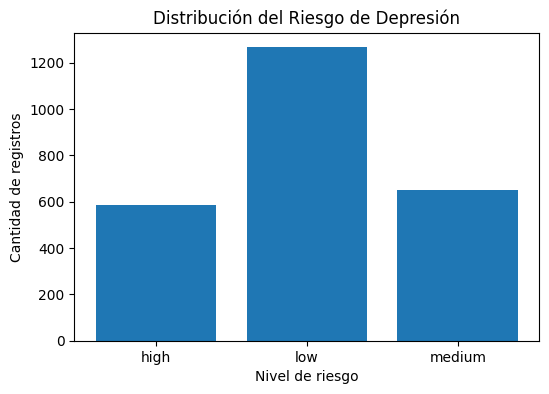

In [0]:
import matplotlib.pyplot as plt

risk_counts = df.groupBy("depression_risk").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(risk_counts["depression_risk"], risk_counts["count"])
plt.title("Distribución del Riesgo de Depresión")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Cantidad de registros")
plt.show()

Muestra cuántos adolescentes están en riesgo bajo, medio o alto de sufrir de depresion

### Promedio de estrés por riesgo de depresión


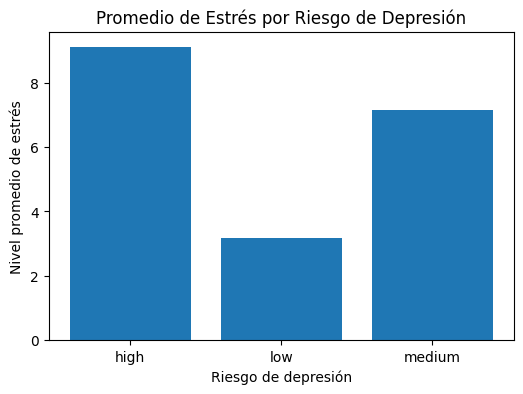

In [0]:
from pyspark.sql.functions import avg

stress_df = df.groupBy("depression_risk") \
              .agg(avg("stress_level").alias("avg_stress")) \
              .toPandas()

plt.figure(figsize=(6,4))
plt.bar(stress_df["depression_risk"], stress_df["avg_stress"])
plt.title("Promedio de Estrés por Riesgo de Depresión")
plt.xlabel("Riesgo de depresión")
plt.ylabel("Nivel promedio de estrés")
plt.show()

Muestra que el estrés aumenta cuando aumenta el riesgo de depresión.

### Promedio de horas de sueño por riesgo de depresión


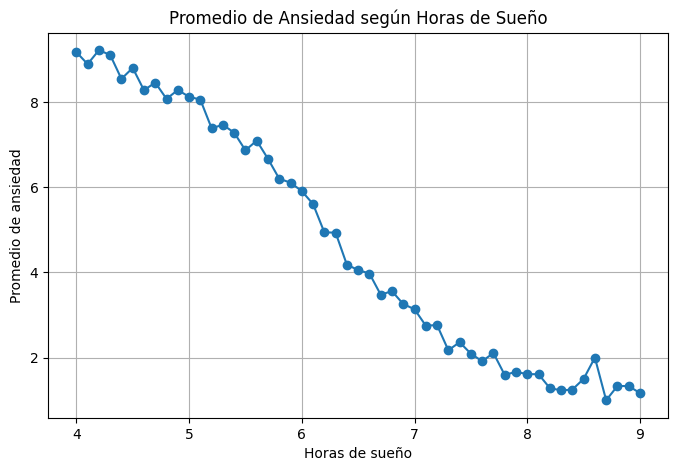

In [0]:
from pyspark.sql.functions import avg
import matplotlib.pyplot as plt

# Promedio de ansiedad según horas de sueño
sleep_anxiety = df.groupBy("sleep_hours") \
    .agg(avg("anxiety_level").alias("avg_anxiety")) \
    .orderBy("sleep_hours")

pdf_sleep = sleep_anxiety.toPandas()

plt.figure(figsize=(8,5))

plt.plot(
    pdf_sleep["sleep_hours"],
    pdf_sleep["avg_anxiety"],
    marker="o"
)

plt.title("Promedio de Ansiedad según Horas de Sueño")
plt.xlabel("Horas de sueño")
plt.ylabel("Promedio de ansiedad")

plt.grid(True)
plt.show()

Esta gráfica muestra el promedio de ansiedad según las horas de sueño reportadas por los adolescentes. 
Muestra que los adolescentes con mayor riesgo de depresión duermen menos.

**conclusión**

La actividad permitió implementar un flujo completo de procesamiento de datos utilizando Apache Spark y Databricks, incluyendo diseño del esquema, validación de calidad, almacenamiento en formato Delta y análisis de información en un entorno cloud. 